In [1]:
%load_ext autoreload
%autoreload 2
from reward_relative.path_dict_seahorse import path_dictionary as path_dict
# from reward_relative import utilities as ut
# from reward_relative import plotUtils as pt
# from reward_relative import spatial
# from reward_relative import placeCellPlot
# from reward_relative import dayData as dd
# from reward_relative import behavior
import pickle
import dill
import numpy as np
import os 
import matplotlib.pyplot as plt
import TwoPUtils
import protter_functions as pf
from scipy.signal import medfilt
from matplotlib.lines import Line2D
import pandas as pd
import umap
import hdbscan
import importlib
import scipy.interpolate as interp
import protter_functions as pf

import protter_plot_functions as ppf
ppf = importlib.reload(ppf)
from protter_plot_functions import add_hover, add_color_selector, ColorSelector, ColorSelectorV2#, #add_selectors
from claude_test_space import add_selectors
from protter_plot_functions import TrialPlotLinker
import matplotlib.cm as cm

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, ListedColormap
import seaborn as sns
from umap.umap_ import nearest_neighbors


import protter_plot_functions as ppf
ppf = importlib.reload(ppf)
from protter_plot_functions import add_hover, add_color_selector, ColorSelector, ColorSelectorV2#, #add_selectors
from claude_test_space import add_selectors
from protter_plot_functions import TrialPlotLinker
pf = importlib.reload(pf)
import traceback

import h5py
plt.rcParams['svg.fonttype'] = 'none'

2026-08-26 16:34:20.686579: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-26 16:34:20.713399: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
all_file = '/data/dave/sosa_data_h5/all_data'
f_all = h5py.File(all_file, "r") 

animal = 'GCAMP12'
day = '7'

In [21]:
events = f_all[animal][day]['neural_events']['neural_events'][:]
hd5_df = pf.recreate_trial_meta_df(f_all[animal][day]['trial_metadata'])
# vr_dat = pf.recreate_trial_meta_df(f_all[animal][day]['vr_data'])
# events_na_free = events[(np.logical_not(np.isnan(events).all(axis = 1)))&(vr_dat.trialnum != -1)]
# vr_dat_na_free = vr_dat.loc[(np.logical_not(np.isnan(events).all(axis = 1)))&(vr_dat.trialnum != -1)]

# events_na_free = events_na_free/np.percentile(events_na_free, 99, axis = 0)
# position = vr_dat_na_free.pos

In [22]:
r_inds = f_all[animal][day]['cell_categories']['reward_cell_indices'][:]

In [23]:
events.shape

(80, 90, 1478)

In [24]:
r_inds_mask = np.zeros(events.shape[-1], dtype = bool)

r_inds_mask[r_inds] = True

In [26]:
r_inds

array([   0,    3,    4,   15,   20,   25,   29,   39,   40,   44,   46,
         47,   53,   57,   59,   64,   69,   71,   90,   94,  104,  105,
        106,  109,  110,  112,  115,  121,  124,  127,  129,  138,  143,
        144,  145,  147,  150,  155,  169,  170,  173,  176,  177,  178,
        179,  187,  199,  202,  203,  210,  222,  248,  251,  255,  256,
        259,  269,  278,  280,  283,  289,  316,  318,  319,  341,  342,
        350,  356,  377,  390,  403,  407,  408,  409,  443,  445,  451,
        467,  474,  476,  477,  491,  492,  493,  494,  498,  508,  514,
        517,  522,  533,  545,  548,  549,  555,  559,  561,  567,  579,
        584,  593,  595,  620,  622,  640,  646,  647,  653,  668,  669,
        675,  680,  701,  703,  715,  721,  722,  723,  728,  729,  769,
        779,  790,  792,  799,  800,  801,  804,  807,  812,  820,  839,
        857,  860,  862,  870,  882,  898,  899,  901,  911,  921,  925,
        928,  929,  932,  934,  937,  950,  959,  9

In [10]:
def normalize_trialmat_by_cell_minmax(arr):
    '''i wonder if this is a bad idea for data with noise. some noise is shared, but
    the magnitude is changed by this norm'''

    #unwrap by cell
    reshaped = arr[:].reshape(-1,arr.shape[-1])
    normed = (reshaped-np.nanmin(reshaped, axis = 0)) / (np.nanmax(reshaped, axis = 0) - np.nanmin(reshaped, axis = 0))

    return normed.reshape(arr.shape[0], arr.shape[1], arr.shape[2])

In [72]:
test = [[1,2]]
test += [[3,4]]

In [73]:
test

[[1, 2], [3, 4]]

In [74]:
################################## positional binned 

save_file = '/data/dave/sosa_data_h5/positional_bin_UMAP_cell_dropout_embeddings'
all_file = '/data/dave/sosa_data_h5/all_data'
f_all = h5py.File(all_file, "r") 

if f_save:
    f_save.close()
f_save = h5py.File(save_file, "w") 

# for animal in f_all.keys():
#     if animal == 'GCAMP5':
#       continue
for animal in [ 'GCAMP14']:
    
    this_animal = f_save.create_group(animal)
    # days = ['4','5' '6', ]
    days = [day for day in f_all[animal].keys() if not day in list(f_save[animal].keys())]
    
    for i, day in enumerate(days):
      
        today = this_animal.create_group(day)
        
        neural_data = f_all[animal][day]['neural_events']['neural_events'][:]


        hd5_df = pf.recreate_trial_meta_df(f_all[animal][day]['trial_metadata'])
        neural_pos_bins = f_all[animal][day]['neural_events']['bin_centers'][:]
        position = np.tile(neural_pos_bins, len(hd5_df))
        
        neural_data = normalize_trialmat_by_cell_minmax(neural_data)


        umap_kwargs = {'n_neighbors' : 80, 'metric' : "cosine", 'output_metric' : "euclidean", 
                        'learning_rate' : 1.0, 'init' : "spectral", 
                        'min_dist' : 0.1, 'spread' : 1.0, 'repulsion_strength' : 1.0, 'negative_sample_rate' : 5, 
                        'target_metric' : "categorical", 'dens_lambda' : 2.0, 'dens_frac' : 0.3, 'dens_var_shift' : 0.1}

        reducer = umap.UMAP(**umap_kwargs)

        #reshape to 2 dims
        neural_data = neural_data.reshape(-1, neural_data.shape[-1])

        embedding_all = reducer.fit_transform(neural_data)


        place_cell_mask = f_all[animal][day]['cell_categories']['overall_place_cell_masks']


        reward_inds = f_all[animal][day]['cell_categories']['reward_cell_indices']
        r_inds_mask = np.zeros(neural_data.shape[-1], dtype = bool)
        r_inds_mask[reward_inds] = True

        embeddings = [[embedding_all, "all"]]

        reducer = umap.UMAP(**umap_kwargs)
        embeddings+= [[ reducer.fit_transform(neural_data[:, np.logical_not(place_cell_mask)]), 'embedding_no_place']]

        reducer = umap.UMAP(**umap_kwargs)
        embeddings+= [[ reducer.fit_transform(neural_data[:, np.logical_not(r_inds_mask)]), 'embedding_no_reward']
]

        reducer = umap.UMAP(**umap_kwargs)
        embeddings+= [[ reducer.fit_transform(neural_data[:,np.logical_not(np.logical_or(r_inds_mask, place_cell_mask))]), 'embedding_no_place_or_reward']]
       

        reducer = umap.UMAP(**umap_kwargs)
        embeddings+= [[ reducer.fit_transform(neural_data[:,place_cell_mask]), 'embedding_place']]


        reducer = umap.UMAP(**umap_kwargs)

        embeddings+= [[ reducer.fit_transform(neural_data[:,r_inds_mask]), 'embedding_reward']]

        reducer = umap.UMAP(**umap_kwargs)
        embeddings+= [[ reducer.fit_transform(neural_data[:,np.logical_or(r_inds_mask, place_cell_mask)]), 'embedding_place_abd_reward']]







        for embedding, name in embeddings:
            today.create_dataset(name, data = embedding)
        for k, v in umap_kwargs.items():
            today.attrs[k] = v

        today.create_dataset('reward_cell_mask', data = r_inds_mask)
        today.create_dataset('overall_place_mask', data = place_cell_mask)

        f_all.copy(f_all[animal][day]['trial_metadata'], today)
        today.create_dataset('neural_bins', data = neural_pos_bins)


   

f_save.close()




In [68]:
import claude_test_space as claude

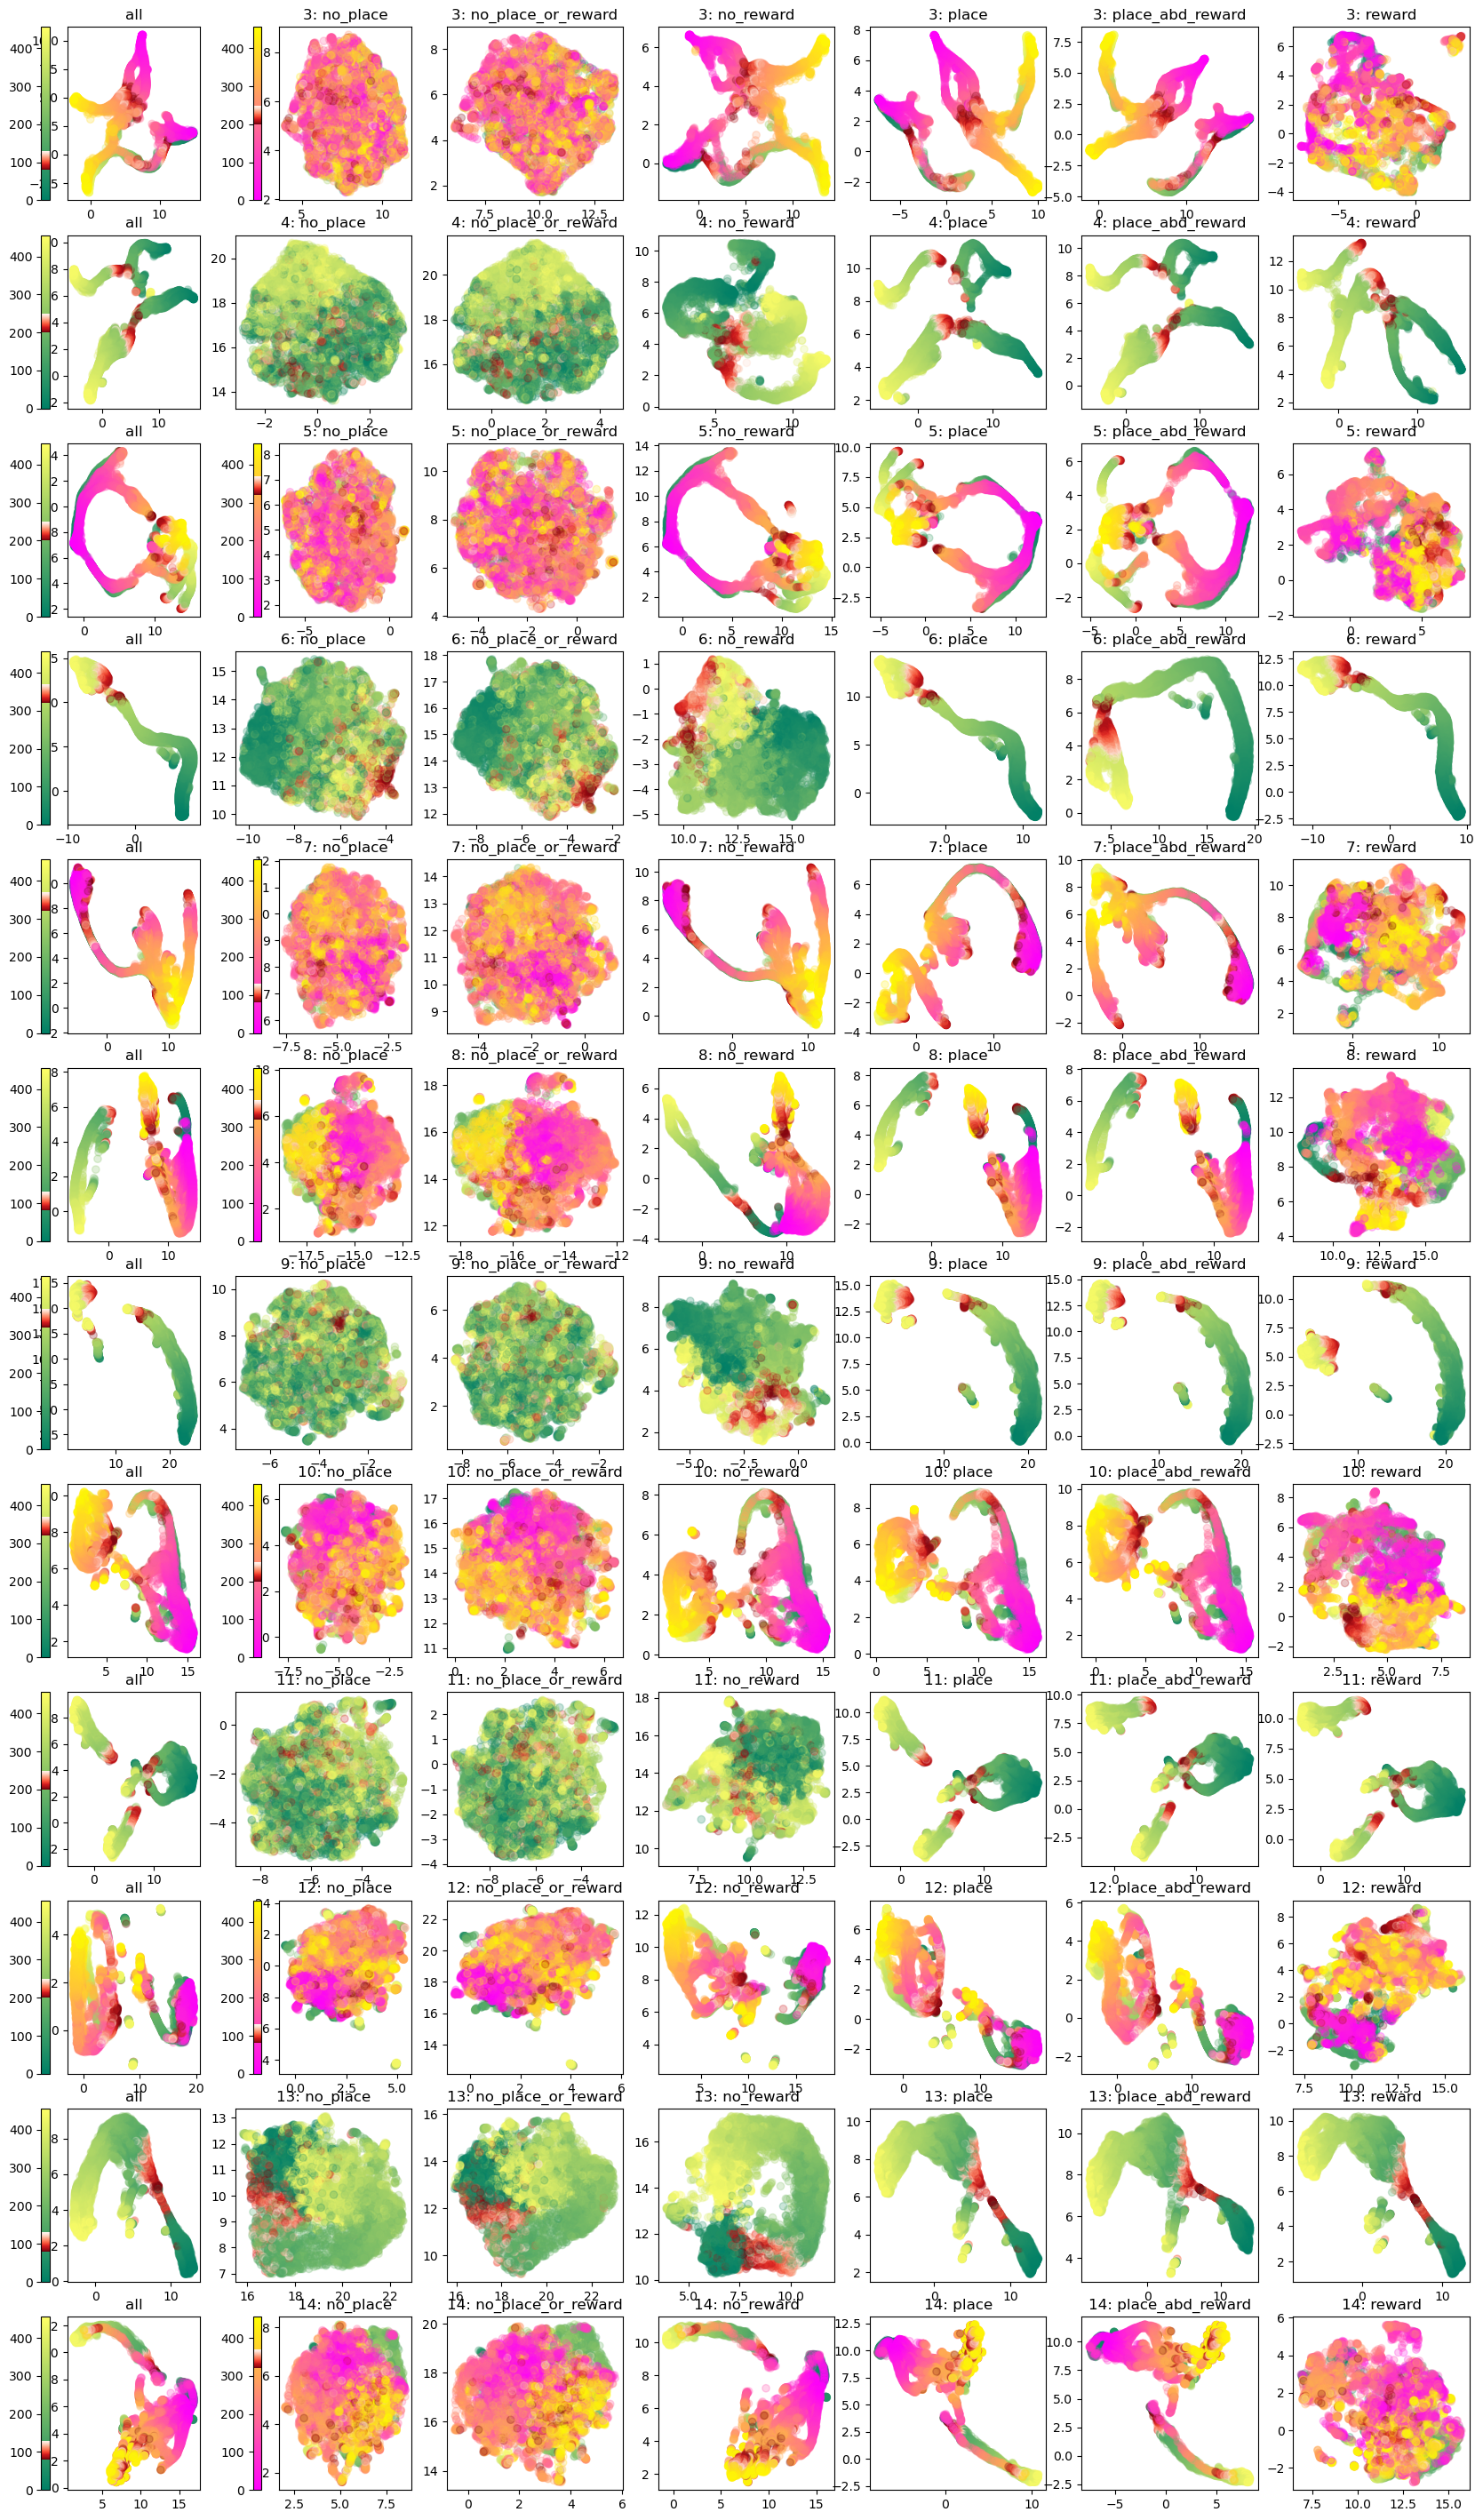

In [81]:
################################## positional binned 

save_file = '/data/dave/sosa_data_h5/positional_bin_UMAP_cell_dropout_embeddings'

with h5py.File(save_file, "r")  as f_embed:
  # for animal in f_all.keys():
  for animal in f_embed.keys():
      if animal == 'GCAMP5':
        continue
      
      # days = ['4', '6', '9', '11', '13']
      days = sorted([day for day in f_embed[animal].keys()], key = int)

      ncols = 7
      fig, axss = plt.subplots(ncols = ncols, nrows = len(days), figsize = (3*ncols, 3*len(days)))
      # for i, day in enumerate(['4', '6', '9', '11', '13']):  #first I just looked at swap days. 
      for i, day in enumerate(days):
        if day in f_all[animal].keys():
          
          axs = axss[i,:]
          

          hd5_df = pf.recreate_trial_meta_df(f_embed[animal][day]['trial_metadata'])
          neural_pos_bins = f_all[animal][day]['neural_events']['bin_centers'][:]
          position = np.tile(neural_pos_bins, len(hd5_df))
          
          

          embedding = f_embed[animal][day]['all'][:]

          r_zones = pf.get_unique_reward_zones_from_meta(hd5_df)
          if len(r_zones) == 1:
            day_swap = False
          else:
            day_swap = True
            

          omit_trials = hd5_df.loc[hd5_df.omit, 'trial']

          omit_bool = hd5_df.trial.isin(omit_trials) 

          scatter_meta = ppf.trial_df_to_position_df(hd5_df, neural_pos_bins)



          kw1 = dict(cmap = 'summer', vmin=0, vmax=456,
            alternate_value_limits=[ r_zones[0]],
            alternate_cmaps=['Reds_r'])

          
          if day_swap:
            kw2 = dict(cmap = 'spring', vmin=0, vmax=456,
                    alternate_value_limits=[r_zones[1]],
                    alternate_cmaps=['Reds_r'])


          
          seg_cmap, norm = claude.make_segmented_cmap(kw1['vmin'], kw1['vmax'],
                                              **{k: v for k, v in kw1.items() if k not in ('vmin', 'vmax')})

          if day_swap:
            seg_cmap2, norm2 = claude.make_segmented_cmap(kw2['vmin'], kw2['vmax'],
                                                        **{k: v for k, v in kw2.items() if k not in ('vmin', 'vmax')})

            c1 = claude.data_to_colors(position[scatter_meta.trial_type == 'pre_swap'],**kw1, alpha = 0.25)
            c2 = claude.data_to_colors(position[scatter_meta.trial_type == 'post_swap'],**kw2, alpha = 0.25)
            c = np.concatenate((c1, c2))
          else:
            c = claude.data_to_colors(position,**kw1, alpha = 0.25)

          

          embed_keys= [k for k in f_embed[animal][day].keys() if 'embedding' in k]

          for ax, k in zip(axs[1:], embed_keys):
            embedding = f_embed[animal][day][k]
            ax.scatter(embedding[:,0], embedding[:,1], c = c)
            ax.set_title(f'{day}: {k.replace("embedding_", "")}')


          embedding = f_embed[animal][day]['all']
          axs[0].scatter(embedding[:,0], embedding[:,1], c = c)
          axs[0].set_title(f'all')



          fig.colorbar(ScalarMappable(norm=norm, cmap=seg_cmap), ax=axs[0], location = 'left', )
          if day_swap:
            fig.colorbar(ScalarMappable(norm=norm2, cmap=seg_cmap2), ax=axs[1], location = 'left', )

          # axs[0].set_title(f'day {day}')

    




In [84]:
f_all[animal]['13'].keys()

<KeysViewHDF5 ['cell_categories', 'lick_data', 'neural_events', 'rewards', 'speed', 'timeseries', 'trial_metadata', 'vr_data']>

In [97]:
f_all[animal]['13']['cell_categories']['reward_cell_indices'][:] 

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  23,  25,  26,  27,  28,
        30,  31,  32,  33,  34,  35,  36,  38,  39,  40,  41,  42,  43,
        44,  46,  47,  48,  50,  51,  52,  53,  55,  56,  57,  58,  59,
        60,  61,  62,  63,  64,  65,  67,  68,  69,  70,  73,  74,  75,
        76,  78,  79,  80,  82,  83,  84,  85,  86,  87,  92,  94,  96,
        97,  98,  99, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
       111, 112, 115, 116, 117, 119, 120, 121, 123, 124, 125, 127, 128,
       129, 130, 131, 132, 133, 134, 135, 137, 139, 141, 142, 144, 145,
       146, 147, 148, 149, 150, 151, 156, 157, 159, 160, 161, 162, 164,
       165, 166, 167, 168, 173, 174, 177, 178, 179, 180, 181, 184, 186,
       188, 189, 191, 192, 195, 196, 197, 201, 202, 203, 204, 205, 207,
       208, 209, 211, 213, 216, 218, 219, 223, 224, 225, 226, 228, 229,
       231, 232, 233, 236, 237, 238, 239, 242, 243, 245, 246, 24

In [96]:
np.where(f_all[animal]['13']['cell_categories']['overall_place_cell_masks'][:])

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  22,  23,  25,  26,  27,
         28,  30,  31,  32,  33,  34,  35,  36,  38,  39,  40,  41,  42,
         43,  44,  45,  46,  47,  48,  50,  51,  52,  53,  55,  56,  57,
         58,  59,  60,  61,  62,  63,  64,  65,  67,  68,  69,  70,  72,
         73,  74,  75,  76,  77,  78,  79,  80,  82,  83,  84,  85,  86,
         87,  91,  92,  94,  96,  97,  98,  99, 101, 102, 103, 104, 105,
        106, 107, 108, 109, 110, 111, 112, 115, 116, 117, 119, 120, 121,
        123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135,
        137, 138, 139, 141, 142, 144, 145, 146, 147, 148, 149, 150, 151,
        153, 155, 156, 157, 159, 160, 161, 162, 164, 165, 166, 167, 168,
        169, 170, 171, 172, 173, 174, 177, 178, 179, 180, 181, 184, 186,
        187, 188, 189, 191, 192, 195, 196, 197, 201, 202, 203, 204, 205,
        206, 207, 208, 209, 211, 212, 213, 214, 216